<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<style>
* { box-sizing: border-box; margin: 0; padding: 0; }
.card{
  font-family: system-ui, -apple-system, sans-serif;
  width:100%;
  border-radius:10px;
  overflow:hidden;
  box-shadow:0 4px 12px rgba(0,0,0,0.12);
  border:1px solid #e5e7eb;
  background:#fcfcfd;
}
.card-header{
  background:#121826;
  padding:16px 20px 14px;
}
.lab-label{
  color:#9ca3af;
  font-size:11px;
  font-weight:600;
  letter-spacing:1.5px;
  text-transform:uppercase;
  margin-bottom:10px;
}
.title-row{
  display:flex;
  align-items:center;
  gap:10px;
  flex-wrap:wrap;
  margin-bottom:5px;
}
.exp-badge{
  background:#3b82f6;
  color:#e0f2fe;
  font-weight:700;
  font-size:12px;
  padding:3px 12px;
  border-radius:9999px;
}
.card-title{
  color:#fff;
  font-size:18px;
  font-weight:700;
}
.card-subtitle{
  color:#94a3b8;
  font-size:13px;
}
.card-body{
  padding:14px 20px 18px;
}
.info-row{
  display:grid;
  grid-template-columns:1fr 1fr;
  padding:10px 0;
  border-bottom:1px dashed #cbd5e1;
}
.info-row:last-of-type{
  border-bottom:none;
}
.info-label{
  color:#475569;
  font-weight:600;
  font-size:13px;
}
.info-value{
  color:#0f172a;
  font-weight:700;
  font-size:13px;
  text-align:right;
}
.note-box{
  background:#e0f2fe;
  color:#0369a1;
  padding:12px 16px;
  border-radius:8px;
  font-size:13px;
  line-height:1.6;
  margin-top:14px;
}
</style>
</head>

<body style="padding:10px;background:transparent;">

<div class="card">

  <div class="card-header">
    <div class="lab-label">Machine Learning Lab</div>

   <div class="title-row">
      <span class="exp-badge">EXP 08</span>
      <span class="card-title">Clustering of Countries with World Bank API</span>
    </div>

<div class="card-subtitle">
      K-Means and Agglomerative Clustering — Unsupervised Learning
    </div>
  </div>

  <div class="card-body">

<div class="info-row">
      <span class="info-label">Student Name</span>
      <span class="info-value">Manav Lakhani</span>
    </div>

<div class="info-row">
      <span class="info-label">Class / Roll No. / Batch</span>
      <span class="info-value">SE-AIML / 35 / A2</span>
    </div>

<div class="info-row">
      <span class="info-label">Subject</span>
      <span class="info-value">Machine Learning Lab</span>
    </div>

<div class="info-row">
      <span class="info-label">Date of Performance</span>
      <span class="info-value">12/03/2026</span>
    </div>

<div class="note-box">
      This experiment focuses on clustering countries based on socio-economic 
      indicators such as GDP per capita, population, life expectancy, and 
      literacy rate using K-Means and Agglomerative clustering techniques 
      with data obtained from the World Bank API.
    </div>

  </div>

</div>

</body>
</html>

### PART 1 : DATASET

In [4]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [5]:
def fetch_indicator(code,year=2022) :
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]

    data = {}
    for item in response:
        country = item['country']['value']
        value = item['value']
        if value is not None:
            data[country] = value
    
    return pd.Series(data, name=code)

In [6]:
gdp = fetch_indicator('NY.GDP.MKTP.CD')
pop = fetch_indicator('SP.POP.TOTL')
life = fetch_indicator('SP.DYN.LE00.IN')
lit = fetch_indicator('SE.ADT.LITR.ZS')

In [7]:
df = pd.concat([gdp, pop, life, lit], axis=1)
df.columns = ['GDP', 'Population', 'LifeExpectancy', 'Literacy']

df.dropna(inplace=True)

In [61]:
df.head()

,GDP,Population,LifeExpectancy,Literacy,KMeansCluster,HierarchicalCluster
Africa Eastern and Southern,1.228968e+12,731821393,64.487020,73.055977,4,2
Africa Western and Central,1.063649e+12,497387180,57.987813,60.780979,1,2
Arab World,3.747417e+12,471352066,71.876096,78.271927,4,1
Central Europe and the Baltics,1.954419e+12,100071871,76.652299,99.479919,0,4
Early-demographic dividend,1.403469e+13,3470644834,71.430455,81.242798,2,1


In [62]:
df.tail(50)

,GDP,Population,LifeExpectancy,Literacy,KMeansCluster,HierarchicalCluster
Sub-Saharan Africa,2.292617e+12,1229208573,61.857180,68.152710,4,2
Sub-Saharan Africa (excluding high income),2.167458e+12,1103704408,61.283354,68.148750,4,2
Sub-Saharan Africa (IDA & IBRD countries),2.292617e+12,1229208573,61.857180,68.152710,4,2
Upper middle income,2.894073e+13,2803106334,76.008959,95.907211,2,3
World,1.022515e+14,7989545217,72.968290,87.392517,3,0
Armenia,1.951351e+10,2969200,74.765854,99.820000,0,4
Bahrain,4.645819e+10,1524693,80.992000,97.870003,0,4
Bangladesh,4.601317e+11,169384897,74.265000,79.000000,0,1
Belize,2.846604e+09,402733,72.190000,87.879997,0,4
Benin,1.742541e+10,13759501,60.475000,51.380001,1,2


In [16]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

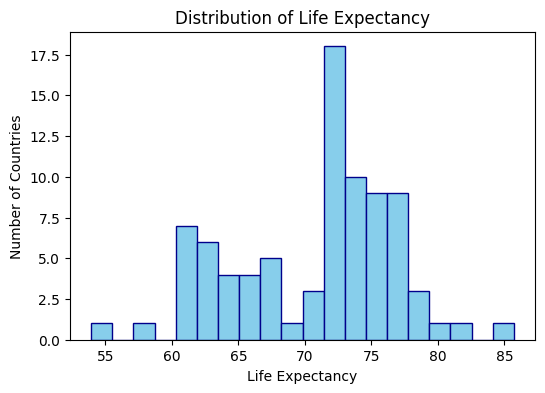

In [19]:
plt.figure(figsize=(6,4))
plt.hist(df["LifeExpectancy"], bins=20, color='skyblue', edgecolor='darkblue')
plt.xlabel('Life Expectancy')
plt.ylabel('Number of Countries')
plt.title('Distribution of Life Expectancy')
plt.show()

### PART 2 : ELBOW METHOD

k	WCSS
1	336.000
2	213.819
3	111.229
4	84.721
5	68.050
6	49.660
7	38.584
8	36.333
9	30.584
10	26.754


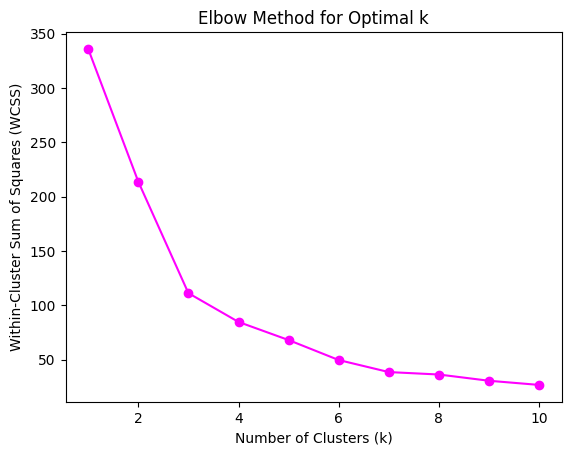

In [24]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

print("k\tWCSS")

for i in range(10):
    print(f"{i+1}\t{wcss[i]:.3f}")

plt.plot(range(1, 11), wcss, marker='o', color='magenta')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.show()

### PART 3 : CLUESTERING ALGORITHMS

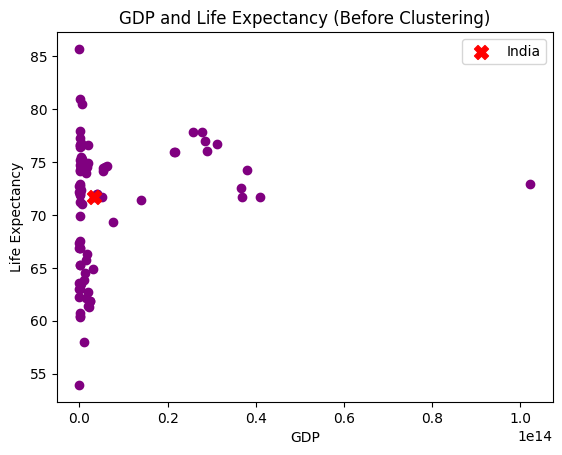

In [69]:
plt.scatter(df["GDP"], df["LifeExpectancy"], color='purple')
plt.xlabel('GDP')
plt.ylabel('Life Expectancy')
plt.title('GDP and Life Expectancy (Before Clustering)')

india = df.loc["India"]
plt.scatter(india["GDP"], india["LifeExpectancy"], color='red', label='India', s=100, marker='X')
plt.legend()
plt.show()

In [37]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels_km = kmeans.fit_predict(scaled_data)

df['KMeansCluster'] = labels_km

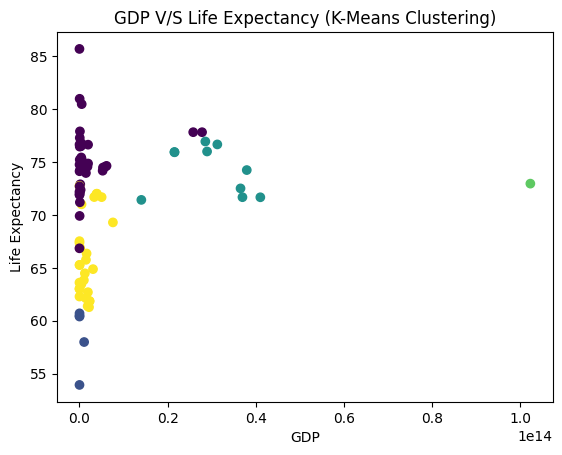

In [44]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_km)
plt.xlabel('GDP')
plt.ylabel('Life Expectancy')
plt.title('GDP V/S Life Expectancy (K-Means Clustering)')
plt.show()

In [50]:
hc = AgglomerativeClustering(n_clusters=5)
labels_hc = hc.fit_predict(scaled_data)

df['HierarchicalCluster'] = labels_hc

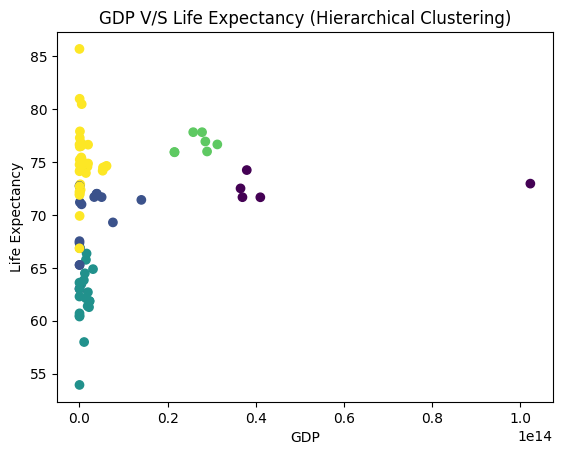

In [48]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_hc)
plt.xlabel('GDP')
plt.ylabel('Life Expectancy')
plt.title('GDP V/S Life Expectancy (Hierarchical Clustering)')
plt.show()

In [51]:
cluster_summary = df.groupby('KMeansCluster')[['GDP', 'Population', 'LifeExpectancy', 'Literacy']].mean()
print(cluster_summary)

                        GDP    Population  LifeExpectancy   Literacy
KMeansCluster                                                       
0              2.312535e+12  1.327261e+08       75.028342  94.954103
1              2.250668e+11  1.153539e+08       58.698363  48.562196
2              2.983491e+13  3.922532e+09       74.309500  91.133104
3              1.022515e+14  7.989545e+09       72.968290  87.392517
4              1.639558e+12  7.382336e+08       66.117221  72.221267


In [ ]:
country_name = "India"

result = df.loc[country_name]

print(f"Country: {country_name}")
print(f"GDP: {result['GDP']}")
print(f"Population: {result['Population']}")
print(f"Life Expectancy: {result['LifeExpectancy']}")
print(f"Literacy: {result['Literacy']}")
print(f"K-Means Cluster: {result['KMeansCluster']}")
print(f"Hierarchical Cluster: {result['HierarchicalCluster']}")

Country: India
GDP: 3346107287730.93
Population: 1425423212.0
Life Expectancy: 71.698
Literacy: 76.3199996948242
K-Means Cluster: 4.0
Hierarchical Cluster: 1.0


In [68]:
for country_name in ["India","North America", "Brazil"] :
    result = df.loc[country_name]
    print(f"Country: {country_name}")
    print(f"GDP: {result['GDP']}")
    print(f"Population: {result['Population']}")
    print(f"Life Expectancy: {result['LifeExpectancy']}")
    print(f"Literacy: {result['Literacy']}")
    print(f"K-Means Cluster: {result['KMeansCluster']}")
    print(f"Hierarchical Cluster: {result['HierarchicalCluster']}")
    print("-" * 50)

Country: India
GDP: 3346107287730.93
Population: 1425423212.0
Life Expectancy: 71.698
Literacy: 76.3199996948242
K-Means Cluster: 4.0
Hierarchical Cluster: 1.0
--------------------------------------------------
Country: North America
GDP: 27803134368745.3
Population: 373018004.0
Life Expectancy: 77.8327679594239
Literacy: 98.7891464233398
K-Means Cluster: 0.0
Hierarchical Cluster: 3.0
--------------------------------------------------
Country: Brazil
GDP: 1951923832083.87
Population: 210306415.0
Life Expectancy: 74.872
Literacy: 94.3853874531348
K-Means Cluster: 0.0
Hierarchical Cluster: 4.0
--------------------------------------------------


In [67]:
for country_name in ["Viet Nam", "Bahrain"] :
    result = df.loc[country_name]
    print(f"Country: {country_name}")
    print(f"GDP: {result['GDP']}")
    print(f"Population: {result['Population']}")
    print(f"Life Expectancy: {result['LifeExpectancy']}")
    print(f"Literacy: {result['Literacy']}")
    print(f"K-Means Cluster: {result['KMeansCluster']}")
    print(f"Hierarchical Cluster: {result['HierarchicalCluster']}")
    print("-" * 50)

Country: Viet Nam
GDP: 413445230668.578
Population: 99680655.0
Life Expectancy: 74.502
Literacy: 96.129997253418
K-Means Cluster: 0.0
Hierarchical Cluster: 4.0
--------------------------------------------------
Country: Bahrain
GDP: 46458191489.3617
Population: 1524693.0
Life Expectancy: 80.992
Literacy: 97.870002746582
K-Means Cluster: 0.0
Hierarchical Cluster: 4.0
--------------------------------------------------
